<a href="https://colab.research.google.com/github/yisuznazi/juegosAjedrez/blob/main/ajedrez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Análisis de Datos y Predicción en Partidas de Ajedrez
**Integrantes:** jesus gonzalez

# Objetivos del Proyecto
1. **Limpieza y Preparación:** Analizar y formatear el dataset de `games.csv` validando tipos de datos y valores nulos.
2. **Análisis Exploratorio :** Responder preguntas de negocio como la distribución de ELO, ventaja del color blanco/negro y las aperturas más exitosas.
3. **Correlación:** Encontrar relaciones matemáticas entre variables numéricas (turnos vs. diferencia de ELO).
4. **Predicción:** Construir un modelo capaz de predecir el ganador de la partida en base a las estadísticas iniciales.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix



In [29]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [30]:
df=pd.read_csv('games.csv')

In [32]:
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,winner_mapped,elo_diff
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,a-00,1191,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,1,309
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,skinnerua,1261,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,0,61
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,a-00,1500,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,1,-4
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,adivanov2009,1454,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,1,-15
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,adivanov2009,1469,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,1,54


In [33]:
df.tail(
)

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,black_id,black_rating,moves,opening_eco,opening_name,opening_ply,winner_mapped,elo_diff
20053,EfqH7VVH,True,1.499791e+12,1.499791e+12,24,resign,white,10+10,belcolt,1691,jamboger,1220,d4 f5 e3 e6 Nf3 Nf6 Nc3 b6 Be2 Bb7 O-O Be7 Ne5...,A80,Dutch Defense,2,1,471
20054,WSJDhbPl,True,1.499698e+12,1.499699e+12,82,mate,black,10+0,jamboger,1233,farrukhasomiddinov,1196,d4 d6 Bf4 e5 Bg3 Nf6 e3 exd4 exd4 d5 c3 Bd6 Bd...,A41,Queen's Pawn,2,0,37
20055,yrAas0Kj,True,1.499698e+12,1.499698e+12,35,mate,white,10+0,jamboger,1219,schaaksmurf3,1286,d4 d5 Bf4 Nc6 e3 Nf6 c3 e6 Nf3 Be7 Bd3 O-O Nbd...,D00,Queen's Pawn Game: Mason Attack,3,1,-67
20056,b0v4tRyF,True,1.499696e+12,1.499697e+12,109,resign,white,10+0,marcodisogno,1360,jamboger,1227,e4 d6 d4 Nf6 e5 dxe5 dxe5 Qxd1+ Kxd1 Nd5 c4 Nb...,B07,Pirc Defense,4,1,133
20057,N8G2JHGG,True,1.499643e+12,1.499644e+12,78,mate,black,10+0,jamboger,1235,ffbob,1339,d4 d5 Bf4 Na6 e3 e6 c3 Nf6 Nf3 Bd7 Nbd2 b5 Bd3...,D00,Queen's Pawn Game: Mason Attack,3,0,-104


In [34]:
df.dtypes

,0
id,object
rated,bool
created_at,float64
last_move_at,float64
turns,int64
victory_status,object
winner,object
increment_code,object
white_id,object
white_rating,int64


asegurarnos de que no hay valores nulos y que las variables categóricas

In [31]:
# 1. Revisar nulos y tipos de datos
print(df.info())
print("\nValores nulos por columna:\n", df.isnull().sum())

# 2. Mapeo de datos: Convertir la columna 'winner' a numérica (1 = blanco, 0 = negro, -1 = empate) para correlaciones
map_winner = {'white': 1, 'black': 0, 'draw': -1}
df['winner_mapped'] = df['winner'].map(map_winner)

# 3. Crear una nueva columna útil: Diferencia de ELO (Fuerza relativa)
df['elo_diff'] = df['white_rating'] - df['black_rating']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  object 
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  object 
 6   winner          20058 non-null  object 
 7   increment_code  20058 non-null  object 
 8   white_id        20058 non-null  object 
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  object 
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  object 
 13  opening_eco     20058 non-null  object 
 14  opening_name    20058 non-null  object 
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), object(9)
memory usage: 2.3+ MB
None

Valo

Antes de realizar cualquier análisis o modelo predictivo, es fundamental conocer la estructura de nuestros datos. Verificaremos los tipos de datos informáticos de cada columna y comprobaremos si existen valores nulos (vacíos) que deban ser eliminados o imputados. Además, realizaremos un mapeo de la columna `winner` para transformarla en valores numéricos y crearemos una nueva variable llamada `elo_diff` (diferencia de ELO), las cuales serán vitales para nuestro análisis de correlación posterior.

In [37]:
df.columns


Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply',
       'winner_mapped', 'elo_diff'],
      dtype='object')

visualizar los tipos de datos



In [35]:
df.shape

(20058, 18)

ver cantidad de datos totales con los cuales se trabajara

In [38]:
# Cuántas partidas gano cada uno agrupado por turnos
ganador_por_turnos = df.groupby(['winner', 'turns']).size().reset_index(name='cantidad_partidas')
print(ganador_por_turnos)

    winner  turns  cantidad_partidas
0    black      1                  2
1    black      2                108
2    black      3                 13
3    black      4                 36
4    black      5                  3
5    black      6                 26
6    black      7                  4
7    black      8                 32
8    black      9                  8
9    black     10                 44
10   black     11                 10
11   black     12                 56
12   black     13                 14
13   black     14                 71
14   black     15                 10
15   black     16                 81
16   black     17                 15
17   black     18                 84
18   black     19                 18
19   black     20                104
20   black     21                 21
21   black     22                 97
22   black     23                 20
23   black     24                114
24   black     25                 25
25   black     26                135
2

In [39]:
# Estadísticas descriptivas de turnos segun ganador
stats_turnos = df.groupby('winner')['turns'].describe()
print(stats_turnos)

          count       mean        std  min   25%   50%     75%    max
winner                                                               
black    9107.0  60.724388  32.369867  1.0  38.0  56.0   78.00  222.0
draw      950.0  86.157895  45.897861  2.0  50.0  89.0  116.75  259.0
white   10001.0  57.790221  32.193353  1.0  35.0  53.0   75.00  349.0


In [40]:
# Diferencia de ELO entre jugadores
df['diferencia_elo'] = abs(df['white_rating'] - df['black_rating'])

# ¿El que tiene mayor ELO suele ganar?
df['gano_mayor_elo'] = (
    ((df['white_rating'] > df['black_rating']) & (df['winner'] == 'white')) |
    ((df['black_rating'] > df['white_rating']) & (df['winner'] == 'black'))
)

print(df['gano_mayor_elo'].value_counts(normalize=True) * 100)

gano_mayor_elo
True     61.581414
False    38.418586
Name: proportion, dtype: float64


Queremos visualizar visualmente las tendencias del juego. Analizaremos quién tiene mayor tasa de victorias y cómo se distribuye el nivel de los jugadores (ELO).

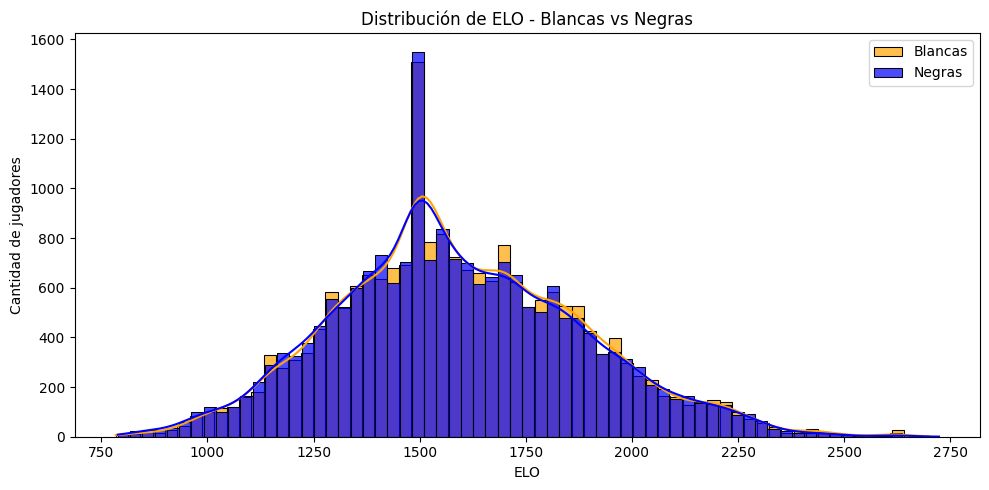

=== ELO Blancas ===
count    20058.000000
mean      1596.631868
std        291.253376
min        784.000000
25%       1398.000000
50%       1567.000000
75%       1793.000000
max       2700.000000
Name: white_rating, dtype: float64

=== ELO Negras ===
count    20058.000000
mean      1588.831987
std        291.036126
min        789.000000
25%       1391.000000
50%       1562.000000
75%       1784.000000
max       2723.000000
Name: black_rating, dtype: float64


In [60]:


# Distribución de ELO blancas vs negras
plt.figure(figsize=(10, 5))
sns.histplot(df['white_rating'], color='orange', edgecolor='black', label='Blancas', kde=True, alpha=0.7)
sns.histplot(df['black_rating'], color='blue', edgecolor='black', label='Negras', kde=True, alpha=0.7)

plt.title("Distribución de ELO - Blancas vs Negras")
plt.xlabel("ELO")
plt.ylabel("Cantidad de jugadores")
plt.legend()
plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("=== ELO Blancas ===")
print(df['white_rating'].describe())
print("\n=== ELO Negras ===")
print(df['black_rating'].describe())

In [42]:
#mucha gente esta en los 1500 de elo, mayor miente son jugadores de negras los que han ganado partidas en eta categoria

=== Conteo de victorias ===
winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

=== Porcentaje ===
winner
white    49.86
black    45.40
draw      4.74
Name: proportion, dtype: float64


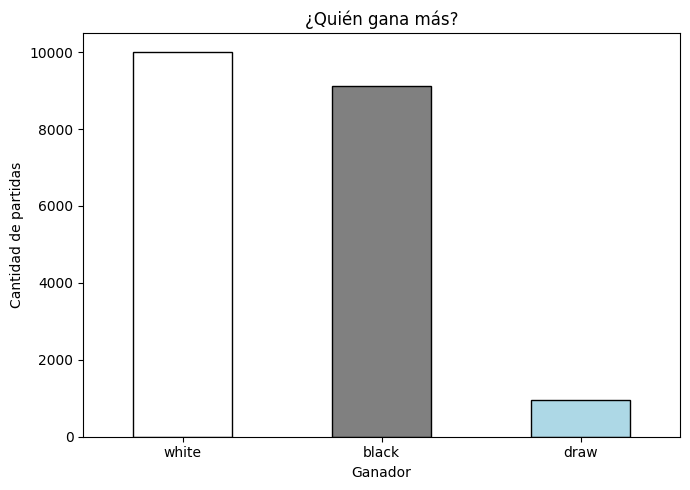

In [43]:
# Conteo de victorias
victorias = df['winner'].value_counts()
porcentaje = df['winner'].value_counts(normalize=True) * 100

print("=== Conteo de victorias ===")
print(victorias)
print("\n=== Porcentaje ===")
print(porcentaje.round(2))

# Gráfico
plt.figure(figsize=(7, 5))
colores = ['white', 'gray', 'lightblue']
victorias.plot(kind='bar', color=colores, edgecolor='black')

plt.title("¿Quién gana más?")
plt.xlabel("Ganador")
plt.ylabel("Cantidad de partidas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Se observa una ligera ventaja competitiva para las piezas blancas, las cuales acumulan un mayor número de victorias en comparación con las piezas negras. Los empates representan una minoría absoluta.



hacer un grafico de calor por que Esto nos permitirá descubrir si existe una relación lineal fuerte entre variables clave; por ejemplo, si una mayor diferencia de ELO asegura la victoria, o si el nivel de los jugadores alarga la cantidad de turnos.

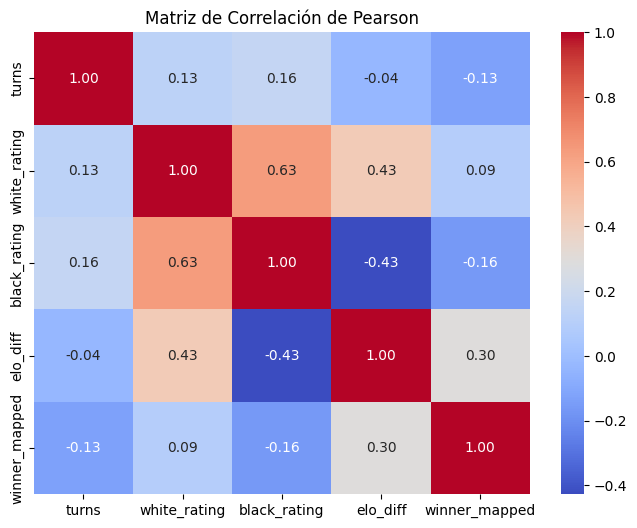

In [56]:
# Seleccionamos variables numéricas clave
columnas_num = ['turns', 'white_rating', 'black_rating', 'elo_diff', 'winner_mapped']
matriz_corr = df[columnas_num].corr()

# Graficamos un Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Pearson')
plt.show()


lo que se destaca del mapa de calor es

El emparejamiento es equilibrado (0.63): correlacion moderada-alta entre el ELO de las piezas blancas (white_rating) y las negras (black_rating). Esto demuestra que el sistema empareja correctamente a jugadores de un nivel de habilidad muy similar.

A mayor nivel, aperturas mas largas (0.28 y 0.26): Existe una leve relacion positiva entre el nivel de los jugadores y la cantidad de movimientos de apertura (opening_ply). Los jugadores con mayor ELO tienden a jugar mas movimientos teoricos de apertura antes del medio juego.

La duracion del juego es impredecible: La variable de turnos totales (turns) tiene colores muy oscuros frente a casi todo (0.13 con el ELO blanco, 0.05 con aperturas). Esto nos dice que el nivel de los jugadores o su apertura no predicen si la partida sera corta o larga.

=== Top 10 aperturas más jugadas ===
opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Name: count, dtype: int64

=== Tasa de victoria por apertura (%) ===
winner                                         black  draw  white
opening_name                                                     
Caro-Kann Defense                              41.71  3.52  54.77
French Defense: Knight Variation               44.65  5.54  49.82
Horwitz Defense                                44.98  2.39  52.63
Indian Game          

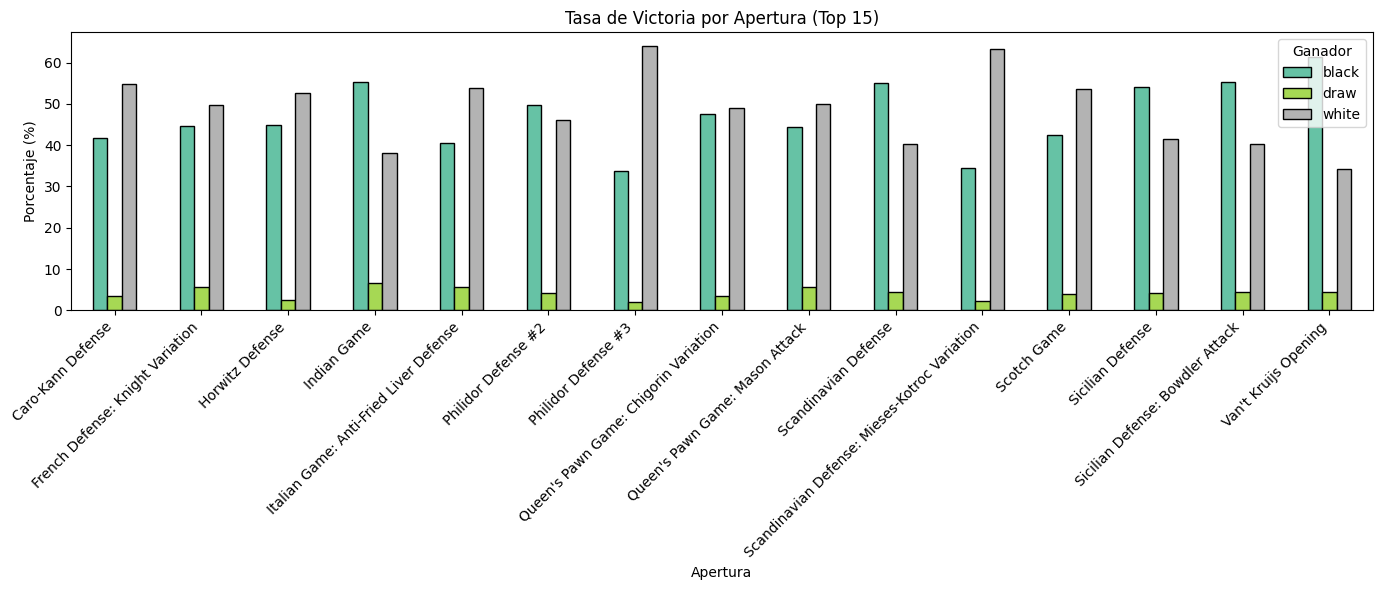

In [46]:
# Top 10 aperturas más jugadas
top_aperturas = df['opening_name'].value_counts().head(10)
print("=== Top 10 aperturas más jugadas ===")
print(top_aperturas)

# Tasa de victoria por apertura (top 16)
top15 = df['opening_name'].value_counts().head(15).index

tasa_victoria = (
    df[df['opening_name'].isin(top15)]
    .groupby('opening_name')['winner']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .unstack()
)

print("\n=== Tasa de victoria por apertura (%) ===")
print(tasa_victoria)

# Gráfico
tasa_victoria.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black')
plt.title("Tasa de Victoria por Apertura (Top 15)")
plt.xlabel("Apertura")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Ganador')
plt.tight_layout()
plt.show()

9 victorias blancas y 6 victorias negras, me parecio interesante agregar este dato sobre las aperturas mas usadas y quienes suelen ganar a usarlas, habiendo pocos empates

hay algun lado el cual se faborece si se alarga el juego?


=== Promedio de opening_ply por ganador ===
winner
black    4.74
draw     5.06
white    4.86
Name: opening_ply, dtype: float64


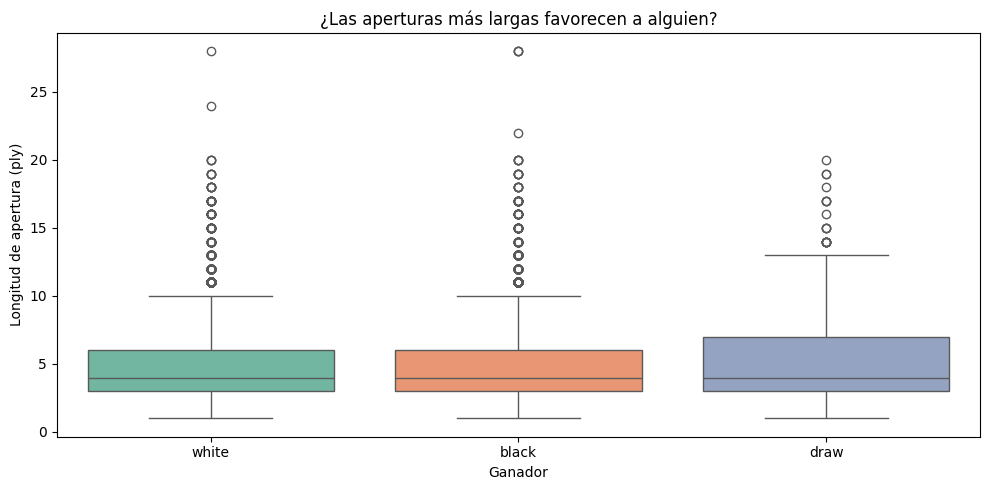


Correlación opening_ply con winner_encoded: 0.0207


In [47]:
# Promedio de opening_ply por ganador
print("=== Promedio de opening_ply por ganador ===")
print(df.groupby('winner')['opening_ply'].mean().round(2))


# Distribución de opening_ply por ganador
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='winner',
    y='opening_ply',
    hue='winner',
    palette='Set2',
    legend=False
    )
plt.title("¿Las aperturas más largas favorecen a alguien?")
plt.xlabel("Ganador")
plt.ylabel("Longitud de apertura (ply)")
plt.tight_layout()
plt.show()

# Correlación opening_ply con winner_encoded
df['winner_encoded'] = df['winner'].map({'white': 1, 'black': -1, 'draw': 0})
correlacion = df['opening_ply'].corr(df['winner_encoded'])
print(f"\nCorrelación opening_ply con winner_encoded: {correlacion:.4f}")

la longitud de la partida no favorece a ninguno, hace que el empate sea mas probable


elo=puntos/clasificacion

=== Top 10 primeras jugadas — BLANCAS ===
moves
e4     12598
d4      4522
Nf3      725
c4       716
e3       416
g3       186
b3       173
f4       166
d3       131
Nc3       99
Name: count, dtype: int64

=== Top 10 primeras jugadas — NEGRAS ===
moves
e5     6988
d5     3667
c5     2883
e6     2083
Nf6    1693
c6      734
d6      543
Nc6     392
g6      387
b6      286
Name: count, dtype: int64


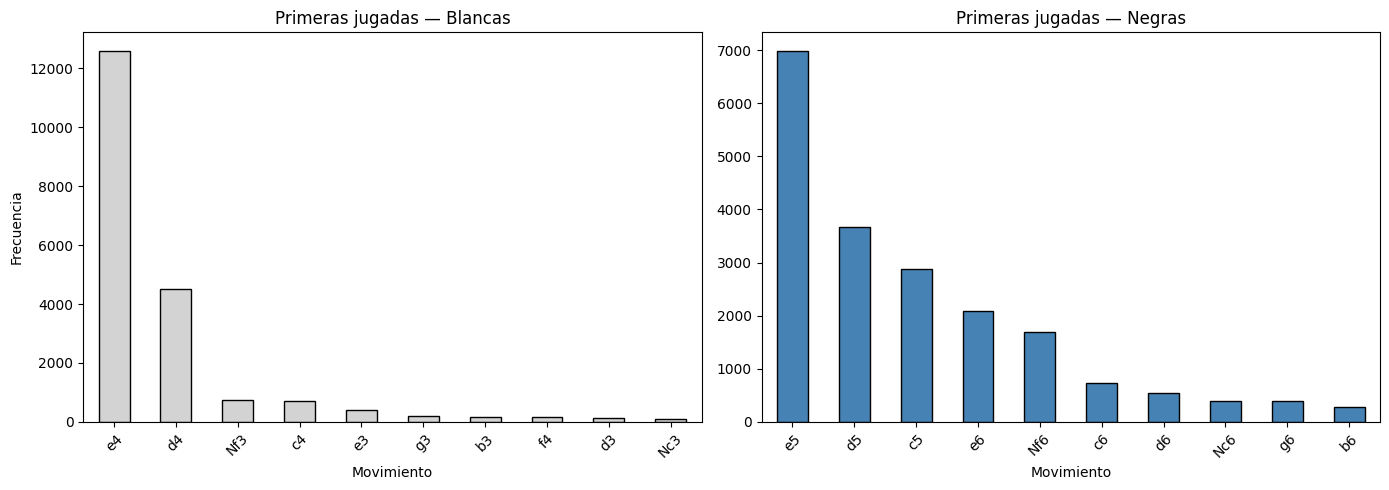

In [50]:
# Extraer solo los primeros N movimientos de cada partida
def primeros_movimientos(moves_series, n=1):
    """Extrae el movimiento número n de cada partida (0=primero, 1=segundo...)"""
    return moves_series.apply(lambda x: x.split()[n] if len(x.split()) > n else None)

# Primer movimiento de blancas (jugada 0)
primer_mov_blancas = primeros_movimientos(df['moves'], 0)
# Primer movimiento de negras (jugada 1)
primer_mov_negras  = primeros_movimientos(df['moves'], 1)

# Top 10 más frecuentes
top_blancas = primer_mov_blancas.value_counts().head(10)
top_negras  = primer_mov_negras.value_counts().head(10)

print("=== Top 10 primeras jugadas — BLANCAS ===")
print(top_blancas)
print("\n=== Top 10 primeras jugadas — NEGRAS ===")
print(top_negras)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_blancas.plot(kind='bar', ax=axes[0], color='lightgray', edgecolor='black')
axes[0].set_title("Primeras jugadas — Blancas")
axes[0].set_xlabel("Movimiento")
axes[0].set_ylabel("Frecuencia")
axes[0].tick_params(axis='x', rotation=45)

top_negras.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title("Primeras jugadas — Negras")
axes[1].set_xlabel("Movimiento")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

primeros movimientos por lado, mostrando cuales tienen mas probabilidades de victoria

=== Top movimientos de BLANCAS cuando GANAN ===
  Nf3: 9558
  e4: 8186
  d4: 7610
  Nc3: 7174
  O-O: 6191
  c4: 3806
  Bc4: 3200
  h3: 3073
  c3: 2992
  Bd3: 2621

=== Top movimientos de NEGRAS cuando GANAN ===
  Nf6: 7944
  Nc6: 6717
  d5: 5659
  e5: 5539
  O-O: 5462
  c5: 4160
  e6: 4015
  d6: 3623
  a6: 2998
  h6: 2917


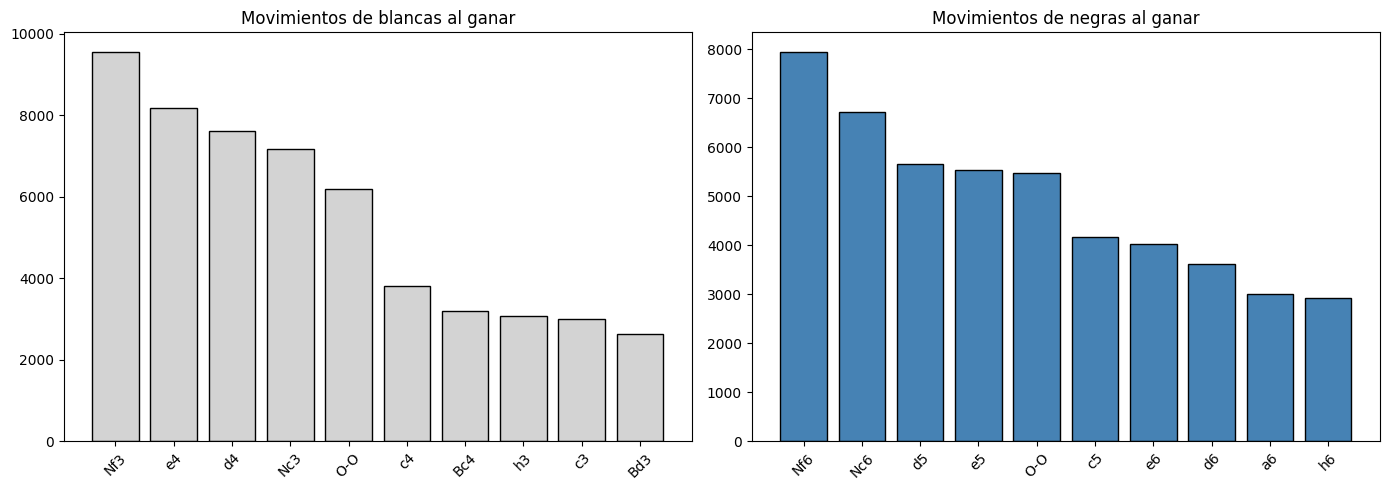

In [51]:
# Separar partidas por ganador
moves_white_wins = df[df['winner'] == 'white']['moves']
moves_black_wins = df[df['winner'] == 'black']['moves']

# Función: extraer todos los movimientos de un lado (pares=blancas, impares=negras)
def movimientos_de_lado(moves_series, lado='blancas', top_n=10):
    todos = []
    for partida in moves_series:
        movs = partida.split()
        if lado == 'blancas':
            todos.extend(movs[::2])   # índices pares
        else:
            todos.extend(movs[1::2])  # índices impares
    return Counter(todos).most_common(top_n)

# Top movimientos cuando ganan blancas
top_blancas_gana = movimientos_de_lado(moves_white_wins, 'blancas')
top_negras_gana  = movimientos_de_lado(moves_black_wins, 'negras')

print("=== Top movimientos de BLANCAS cuando GANAN ===")
for mov, freq in top_blancas_gana:
    print(f"  {mov}: {freq}")

print("\n=== Top movimientos de NEGRAS cuando GANAN ===")
for mov, freq in top_negras_gana:
    print(f"  {mov}: {freq}")

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

movs_b, freqs_b = zip(*top_blancas_gana)
movs_n, freqs_n = zip(*top_negras_gana)

axes[0].bar(movs_b, freqs_b, color='lightgray', edgecolor='black')
axes[0].set_title("Movimientos de blancas al ganar")
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(movs_n, freqs_n, color='steelblue', edgecolor='black')
axes[1].set_title("Movimientos de negras al ganar")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

primeros movimientos por blancas y negras los cuales desenlazan una victoria mas seguido

In [52]:
#NF3= CABALLO A F3
#0-0 ENROQUE CORTO
#BC4 ALFIL A B4
#BD3 mover la reina blanca en diagonal para atrapar al rey negro
#NF6 caballo  a la casilla f6
#NC6 movimiento del caballo negro a la casilla c6